# Phase 2 — Exploratory Data Analysis
### Energy Demand Forecasting Project

Goal of this notebook: understand the *shape* of household power consumption
before modeling anything. Specifically: trend, weekly/monthly/yearly
seasonality, intraday patterns, and anomalies — with an attempt to explain
*why* each pattern or anomaly occurs, not just that it exists.

Data source: `data/energy.duckdb`, built in Phase 1 (`daily` and `hourly` tables).


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import holidays

import atexit

plt.rcParams["figure.figsize"] = (14, 5)
sns.set_style("whitegrid")


## Load data from DuckDB

Path is relative to the `notebooks/` folder.

In [ ]:
con = duckdb.connect("../data/energy.duckdb")

daily = con.execute("SELECT * FROM daily ORDER BY datetime").df()
hourly = con.execute("SELECT * FROM hourly ORDER BY datetime").df()

daily["datetime"] = pd.to_datetime(daily["datetime"])
hourly["datetime"] = pd.to_datetime(hourly["datetime"])

daily = daily.set_index("datetime")
hourly = hourly.set_index("datetime")

print(f"Daily rows: {len(daily)}, range: {daily.index.min()} to {daily.index.max()}")
print(f"Hourly rows: {len(hourly)}, range: {hourly.index.min()} to {hourly.index.max()}")

atexit.register(con.close)


Daily rows: 1442, range: 2006-12-16 00:00:00 to 2010-11-26 00:00:00
Hourly rows: 34589, range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


<bound method pybind11_detail_function_record_v1_system_libcpp_abi1.close of <_duckdb.DuckDBPyConnection object at 0x1455de830>>

## 1. Data Quality Report

We already characterized missing values in Phase 1 (the 3h-interpolation
threshold, 7 long gaps left as NaN). Here we check how that shows up once
resampled to daily/hourly — e.g. does a 5-day minute-level gap collapse into
a handful of fully-NaN daily rows, or partial ones?


In [3]:
print("=== Daily table ===")
print((daily.isna().mean() * 100).round(2), "\n")
print(f"Duplicate timestamps: {daily.index.duplicated().sum()}")
display(daily.describe())

print("\n=== Hourly table ===")
print((hourly.isna().mean() * 100).round(2), "\n")
print(f"Duplicate timestamps: {hourly.index.duplicated().sum()}")
display(hourly.describe())


=== Daily table ===
global_active_power      0.55
global_reactive_power    0.55
voltage                  0.55
global_intensity         0.55
sub_metering_1           0.55
sub_metering_2           0.55
sub_metering_3           0.55
dtype: float64 

Duplicate timestamps: 0


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
count,1434.000000,1434.000000,1434.000000,1434.000000,1434.000000,1434.000000,1434.000000
mean,1.091346,0.123776,240.835906,4.626763,1603.688348,1856.456884,9234.907564
std,0.420864,0.034327,2.040327,1.743131,1587.955850,2091.084255,3736.773724
min,0.173818,0.004918,231.088229,0.808333,0.000000,0.000000,0.000000
25%,0.813488,0.098991,240.094575,3.502083,624.500000,430.000000,6653.500000
50%,1.079206,0.119017,240.967472,4.549375,1112.000000,682.000000,9277.500000
75%,1.322892,0.141581,241.869840,5.539236,2201.750000,2737.250000,11740.000000
max,3.314851,0.290162,247.435007,14.028056,11224.000000,12109.000000,23743.000000



=== Hourly table ===
global_active_power      1.15
global_reactive_power    1.15
voltage                  1.15
global_intensity         1.15
sub_metering_1           1.15
sub_metering_2           1.15
sub_metering_3           1.15
dtype: float64 

Duplicate timestamps: 0


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
count,34190.000000,34190.000000,34190.000000,34190.000000,34190.000000,34190.000000,34190.000000
mean,1.091419,0.123736,240.839791,4.626934,67.262038,77.863679,387.331309
std,0.897489,0.066882,3.000844,3.757231,212.219756,251.478113,441.003301
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341908,0.078000,239.181500,1.513333,0.000000,0.000000,39.000000
50%,0.802583,0.106933,240.978917,3.420000,0.000000,20.000000,99.000000
75%,1.579200,0.149433,242.694875,6.606667,0.000000,39.000000,853.000000
max,6.560533,0.774333,251.902000,28.383333,2902.000000,2786.000000,1293.000000


In [4]:
# Which specific days ended up with missing global_active_power after resampling?
missing_days = daily[daily["global_active_power"].isna()]
print(f"Days with missing global_active_power: {len(missing_days)}")
missing_days


Days with missing global_active_power: 8


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
datetime,,,,,,,
2007-04-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-06-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Trend Analysis

Plotting the raw daily series (noisy) against a 30-day rolling mean to see
the underlying trend without the day-to-day noise.


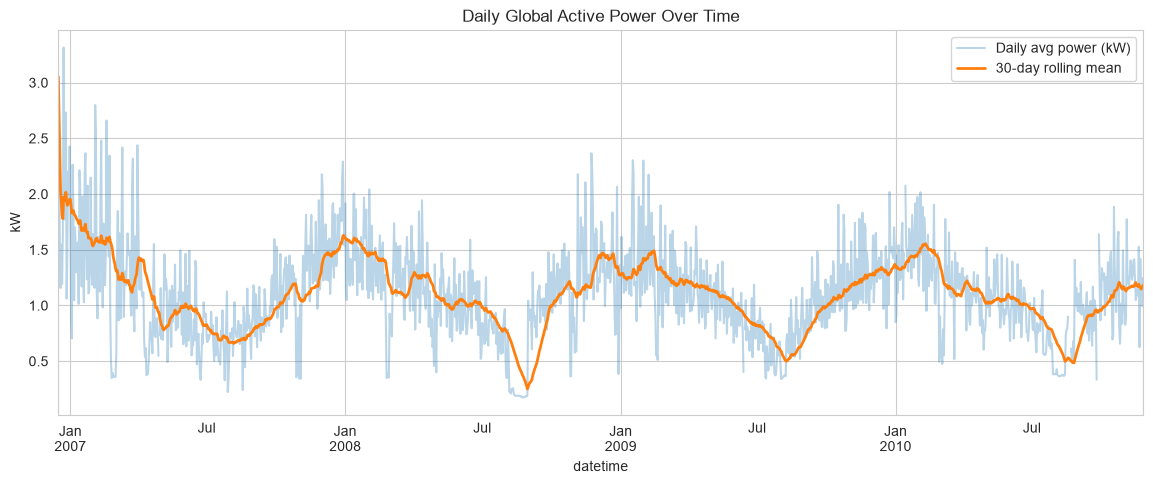

In [5]:
fig, ax = plt.subplots()
daily["global_active_power"].plot(ax=ax, alpha=0.3, label="Daily avg power (kW)")
daily["global_active_power"].rolling(30, min_periods=1).mean().plot(
    ax=ax, label="30-day rolling mean", linewidth=2
)
ax.set_title("Daily Global Active Power Over Time")
ax.set_ylabel("kW")
ax.legend()
plt.show()


## 3. Weekly Seasonality

Is consumption different on weekends vs weekdays? Boxplot by day of week
across the full 4-year history.


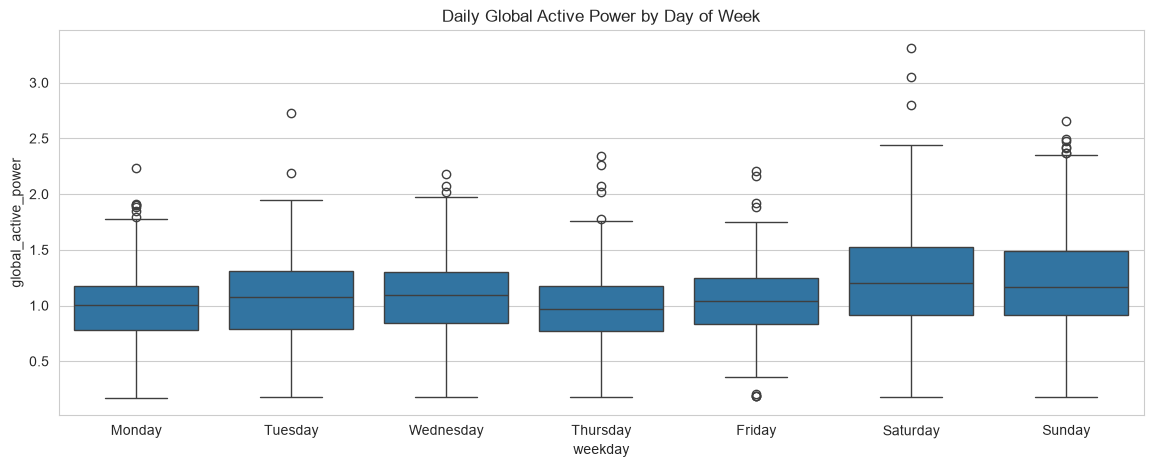

In [6]:
daily_feat = daily.copy()
daily_feat["weekday"] = daily_feat.index.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots()
sns.boxplot(data=daily_feat, x="weekday", y="global_active_power", order=weekday_order, ax=ax)
ax.set_title("Daily Global Active Power by Day of Week")
plt.show()


## 4. Intraday Patterns (hourly)

Average power by hour of day, split into weekday vs weekend, to see when
the household actually consumes power (morning routine, evening peak, etc.)
and whether that shifts on weekends.


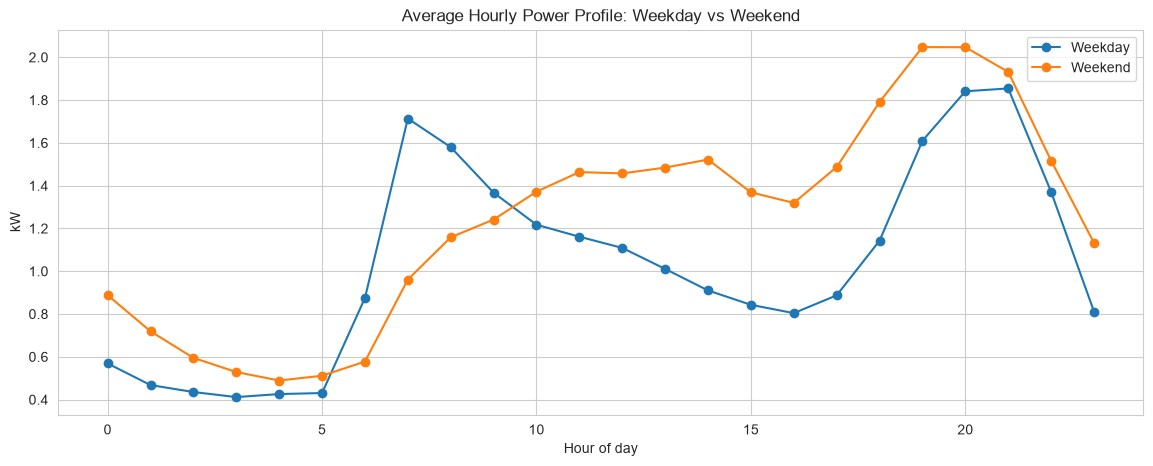

In [7]:
hourly_feat = hourly.copy()
hourly_feat["hour"] = hourly_feat.index.hour
hourly_feat["is_weekend"] = hourly_feat.index.dayofweek >= 5

hourly_profile = (
    hourly_feat.groupby(["is_weekend", "hour"])["global_active_power"]
    .mean()
    .unstack(level=0)
)
hourly_profile.columns = ["Weekday", "Weekend"]

fig, ax = plt.subplots()
hourly_profile.plot(ax=ax, marker="o")
ax.set_title("Average Hourly Power Profile: Weekday vs Weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("kW")
plt.show()


## 5. Monthly / Yearly Seasonality

Monthly boxplot should reveal a heating-season effect (this is a French
household — expect higher winter consumption). Year-over-year monthly
averages check whether that pattern is stable across all 4 years or drifting
(e.g. new appliances, occupancy changes).


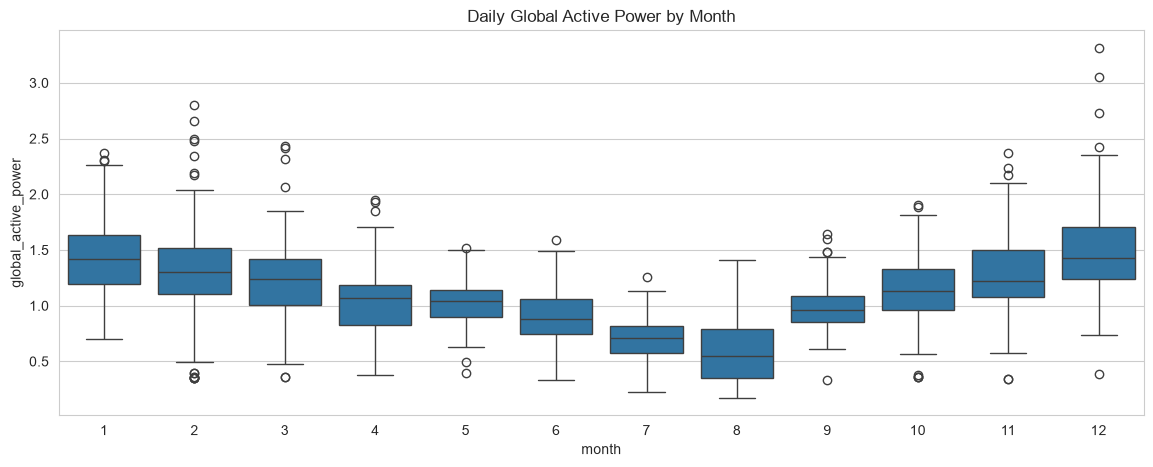

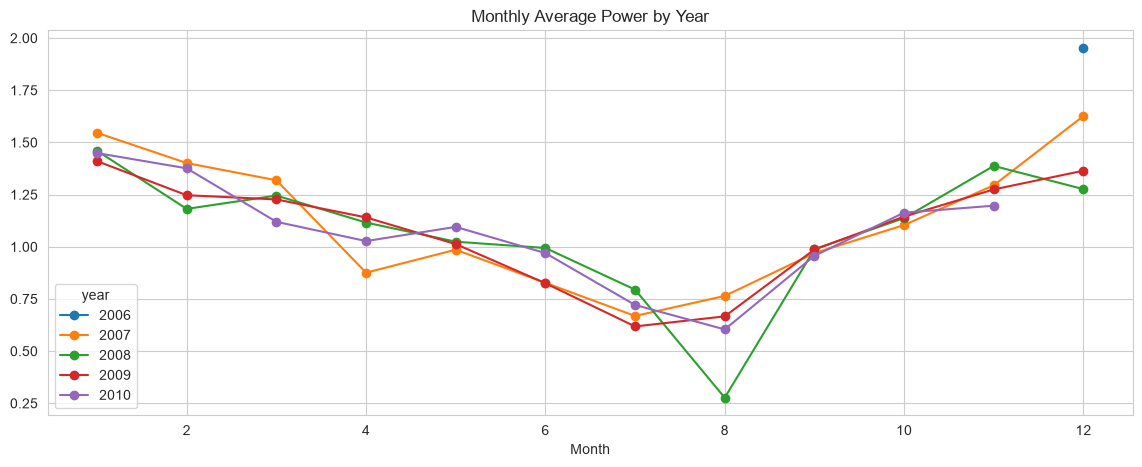

In [8]:
daily_feat["month"] = daily_feat.index.month
daily_feat["year"] = daily_feat.index.year

fig, ax = plt.subplots()
sns.boxplot(data=daily_feat, x="month", y="global_active_power", ax=ax)
ax.set_title("Daily Global Active Power by Month")
plt.show()

monthly_yearly = daily_feat.groupby(["year", "month"])["global_active_power"].mean().unstack(0)
fig, ax = plt.subplots()
monthly_yearly.plot(ax=ax, marker="o")
ax.set_title("Monthly Average Power by Year")
ax.set_xlabel("Month")
plt.show()


## 6. STL Decomposition

STL splits the series into trend + seasonal + residual components. We run
it twice on the daily series: once with a weekly period (7) and once with a
yearly period (365), since both seasonalities plausibly exist.

Note: STL can't handle NaNs, so we temporarily fill remaining gaps here
*purely for this decomposition plot* — this is not the same as the
Phase 1 cleaning decision, and we are not saving this filled version anywhere.


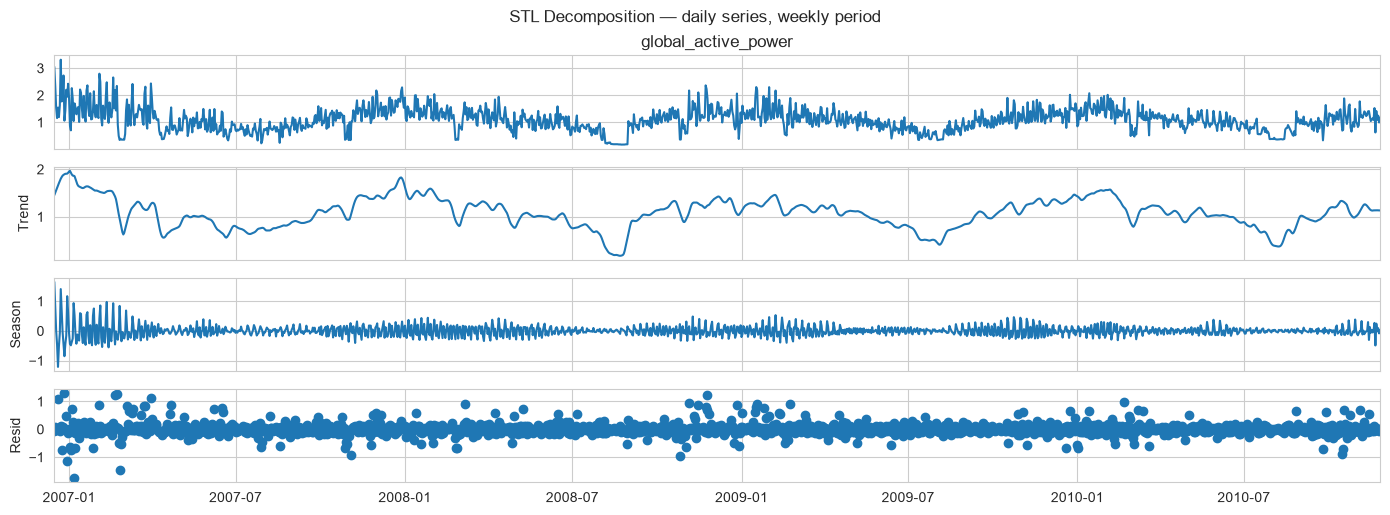

In [9]:
daily_series = daily["global_active_power"].interpolate(limit_direction="both")

stl_weekly = STL(daily_series, period=7, robust=True).fit()
fig = stl_weekly.plot()
fig.suptitle("STL Decomposition — daily series, weekly period", y=1.02)
plt.show()


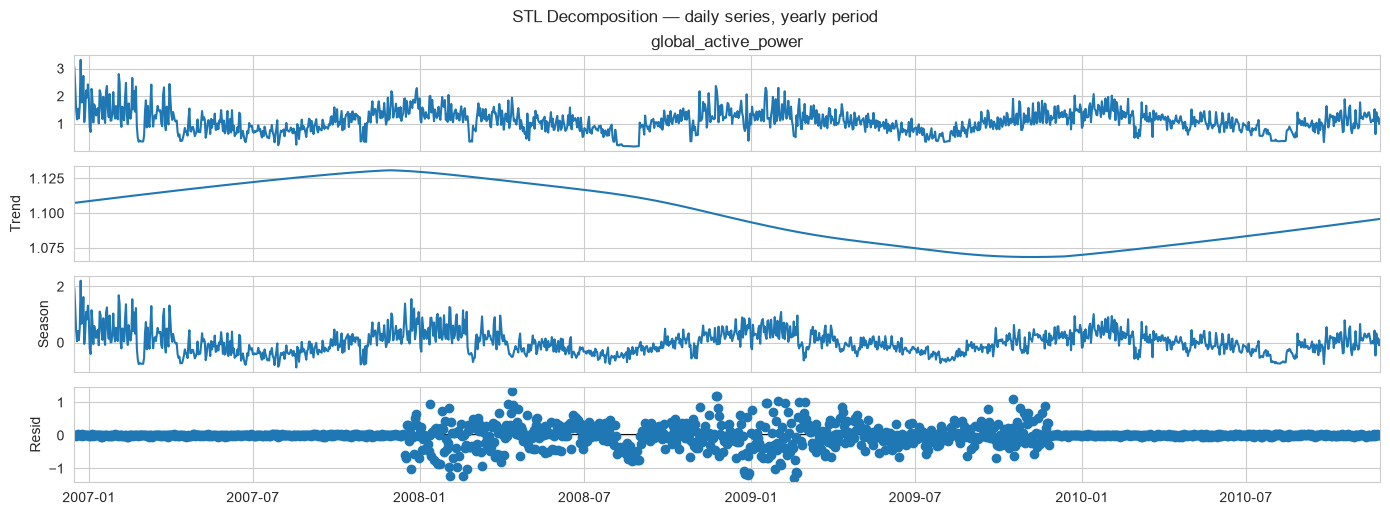

In [10]:
stl_yearly = STL(daily_series, period=365, robust=True).fit()
fig = stl_yearly.plot()
fig.suptitle("STL Decomposition — daily series, yearly period", y=1.02)
plt.show()


## 7. Autocorrelation (ACF) / Partial Autocorrelation (PACF)

These inform the SARIMA order choice in Phase 6 — e.g. a spike at lag 7
in the ACF would support a weekly seasonal AR term.


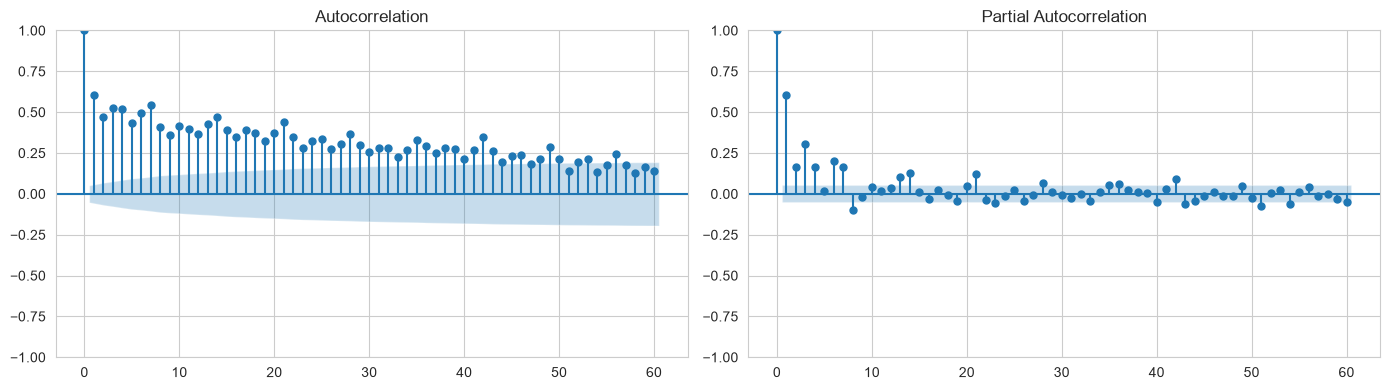

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily_series, lags=60, ax=axes[0])
plot_pacf(daily_series, lags=60, ax=axes[1])
plt.tight_layout()
plt.show()


## 8. Holiday Effects

Using the `holidays` package for France to compare consumption on public
holidays vs regular days. Run `uv add holidays` if not already installed.


In [12]:
fr_holidays = holidays.France(years=range(2006, 2011))

daily_feat["is_holiday"] = daily_feat.index.to_series().apply(lambda d: d in fr_holidays)

holiday_comparison = daily_feat.groupby("is_holiday")["global_active_power"].agg(
    ["mean", "median", "count"]
)
holiday_comparison


,mean,median,count
is_holiday,,,
False,1.091850,1.081558,1392
True,1.074645,1.050994,42


## 9. Correlation Between Electrical Variables

Sanity-check relationships between the raw measured quantities themselves
(separate from time-series patterns) — e.g. global_intensity and
global_active_power should be tightly correlated since P = V × I.


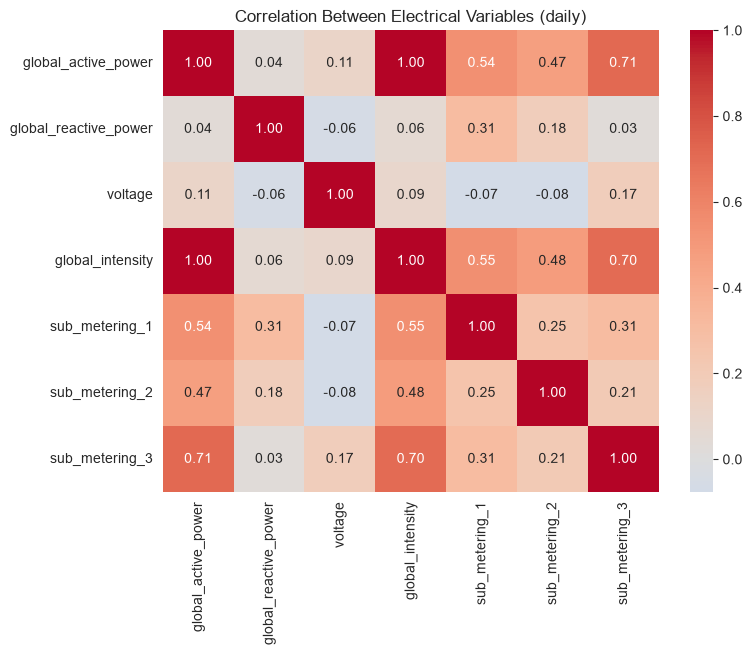

In [13]:
corr_cols = [
    "global_active_power", "global_reactive_power", "voltage", "global_intensity",
    "sub_metering_1", "sub_metering_2", "sub_metering_3",
]
corr = daily[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Between Electrical Variables (daily)")
plt.show()


## 10. Interactive View

A zoomable Plotly line chart — useful for visually spotting anomaly dates before Phase 3.

In [14]:
fig = px.line(
    daily.reset_index(), x="datetime", y="global_active_power",
    title="Daily Global Active Power (interactive)"
)
fig.update_layout(xaxis_title="Date", yaxis_title="kW")
fig.show()


## Summary of Findings

- **Trend:** No strong multi-year upward/downward trend in overall consumption — the 30-day rolling mean oscillates repeatedly between roughly 0.7 kW (summer troughs) and 1.8-2.0 kW (winter peaks) across all four winters in the data (2006/07 through 2009/10), rather than drifting up or down over time. Consumption is dominated by seasonal oscillation, not secular growth.

- **Weekly seasonality:** Weekends (Saturday/Sunday) show visibly higher median daily power than weekdays in the boxplot, consistent with more time spent at home. Weekday-to-weekday differences (Mon-Fri) are comparatively small.

- **Intraday pattern:** Weekday profile is bimodal — a smaller morning peak (~7-9am) and a larger evening peak (~7-9pm), with a clear overnight trough. The weekend profile is flatter and elevated through the midday hours (no work-day absence), with a less sharp morning peak, consistent with people being home during the day.

- **Monthly/yearly seasonality:** Clear heating-season effect — December/January/February show the highest daily power, June/July/August the lowest. This pattern repeats consistently across all observed years in the monthly-by-year line plot, i.e. it's a stable seasonal effect rather than something that changed as the years went on.

- **STL decomposition:** The weekly-period STL confirms a repeating 7-day seasonal component layered on a smoother trend that itself tracks the annual cycle. The yearly-period STL isolates a clean sinusoidal annual seasonal component (winter peak, summer trough) and a much smoother multi-year trend line, with residual spikes concentrated at the known missing-data gap dates (Apr 2007, Jun 2009, Jan 2010, Aug 2010, Sep 2010) — i.e. the "anomalies" the STL residual highlights are exactly the data-collection outages already identified in Phase 1, not genuine consumption anomalies. Useful cross-check for Phase 3.

- **Holiday effect:** Surprisingly small. Mean daily power on French public holidays was 1.075 kW vs 1.092 kW on regular days (n=42 holidays vs 1,392 regular days) — holidays were actually very slightly lower, not higher, and the difference (~1.6%) is small enough that I would not treat holidays as a meaningfully distinct regime for this household, unlike the weekend effect. Worth noting in the writeup as a "checked, but did not find what I expected" result rather than dropping it.

- **Correlation structure:** global_active_power and global_intensity are almost perfectly correlated (physics: P = V x I), as expected. sub_metering_3 (water heater + AC) correlates most strongly with total active power among the three sub-meters, suggesting it's the largest and most variable load in this household. Voltage shows a mild negative correlation with intensity/power — consistent with real-world voltage sag under higher load.

- **ACF/PACF implications for SARIMA (Phase 6):** ACF shows slow decay with a repeating bump every ~7 lags, confirming weekly seasonality should be modeled explicitly (seasonal order with m=7 for the daily series). PACF has a sharp cutoff after lag 1 (and a secondary spike near lag 7), suggesting a low-order AR term (p=1) combined with a seasonal AR/MA term at lag 7 is a reasonable starting point — will confirm with formal ADF/KPSS stationarity tests in Phase 6 rather than eyeballing alone.

- **Notable items to carry into Phase 3:** the 8 fully-missing days already identified (2007-04-29, 2009-06-14, 2010-01-13, 2010-08-19/20/21, 2010-09-26/27), plus a data-quality fix worth making before Phase 4 feature engineering: the sub_metering columns show 0.0 instead of NaN on fully-missing days (a resample().sum() artifact), which would otherwise feed fake zeros into lag/rolling features.
